# Reduce and run cells from AllenDB

In [1]:
# !pip install --upgrade numpy==1.24.4 pandas==2.2.2 scipy==1.11.3> /dev/null 2>&1

# import os
# os.kill(os.getpid(), 9)#restart so the above packages can be used

In [2]:
# If running in Colab
!pip install --upgrade pip2 > /dev/null 2>&1
!git clone -b release_candidate https://github.com/V-Marco/ACT.git > /dev/null 2>&1

#choose specimen id and model type

In [3]:
# Mouse L2/3 PV cell
# https://celltypes.brain-map.org/experiment/electrophysiology/484635029
specimen_id = 484635029

model_type = 'perisomatic'#or 'all active'
work_dir = 'OriginalFromAllenDB'

In [4]:
from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils
from neuron import h
import os
import json
import matplotlib.pyplot as plt
import math
import numpy as np
import sys
sys.path.append("ACT")
from act.passive import ACTPassiveModule

# If error, restart env

--No graphics will be displayed.
/home/hrbncv/miniconda3/envs/BMTK/lib/python3.9/site-packages/torch/__init__.py:1240: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


#Also if using hoc, double check parameters every time build_cell() is used

In [5]:
#get the model id

bp = BiophysicalApi()#using AllenDB's API
models = bp.get_neuronal_models(specimen_id)

for model in models:
  if model_type in model['name'].lower():
    print(f"model id = {model['id']}\n")
    model_id = model['id']
models

model id = 485602029



[{'id': 485602029,
  'name': 'Biophysical - perisomatic_Pvalb-IRES-Cre;Ai14-201791.05.01.01',
  'neuron_reconstruction_id': 496079599,
  'neuronal_model_template_id': 329230710,
  'specimen_id': 484635029},
 {'id': 496538965,
  'name': 'Biophysical - all active_Pvalb-IRES-Cre;Ai14-201791.05.01.01',
  'neuron_reconstruction_id': 496079599,
  'neuronal_model_template_id': 491455321,
  'specimen_id': 484635029}]

## Build the cell

add vecstim, cpampain.mod,NMDAIN.mod from https://github.com/yzerlaut/pv-sst-dendrites/tree/main/detailed_model and compile

if you need additonal modfiles from a public repo, provide a list of the names of the modfiles and a link to the folder

In [6]:
# Compile the modfiles
os.chdir(work_dir)
!nrnivmodl modfiles > /dev/null 2>&1

In [7]:
import sys, os
from functools import wraps

def suppress_output(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        devnull = open(os.devnull, 'w')
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = devnull
        try:
            return fn(*args, **kwargs)
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr
            devnull.close()
    return wrapper

**NOTE:** Control the soma area in the `build_cell` function below.

In [8]:
@suppress_output
def build_cell(soma_diam_multiplier = 1,using_hoc=False,hoc_filename=None,cell_name=None):

    if using_hoc:
      from neuron import h
      h.load_file(hoc_filename)
      return getattr(h, cell_name)()
    # Create the h object
    description = Config().load('manifest.json')
    utils = Utils(description)
    h = utils.h
    # Convert all "value" attributes to floats
    for dict in utils.description.data['genome']:
        for key, value in dict.items():
            if key == 'value': dict[key] = float(value)
    # Configure morphology
    morphology_path = description.manifest.get_path('MORPHOLOGY')
    utils.generate_morphology(morphology_path.encode('ascii', 'ignore'))
    utils.load_cell_parameters()
    # To match PP
    h.soma[0].diam = h.soma[0].diam * soma_diam_multiplier

    return h

In [9]:
soma_diam_multiplier = 6
hobject = build_cell(soma_diam_multiplier)
h.define_shape()

1.0

In [10]:
print(f"Soma area: {hobject.soma[0](0.5).area()}")
print(f"Soma diam: {hobject.soma[0].diam}")
print(f"Soma L: {hobject.soma[0].L}")

# print(f"Axon area: {hobject.axon[0](0.5).area()}")
# print(f"Axon diam: {hobject.axon[0].diam}")
# print(f"Axon L: {hobject.axon[0].L}")

Soma area: 4017.876017303496
Soma diam: 87.59880065917969
Soma L: 14.599853515625


Cell Morphology

In [11]:
soma_roots = hobject.soma[0].children()
print(f'Root dendrites: {soma_roots}')

# h.topology()

Root dendrites: [axon[0], dend[36], dend[31], dend[24], dend[23], dend[22], dend[0]]


Section Details

In [12]:
from neuron import h

def segment_properties(sec):
    """
    Return a list of dicts—one per segment in `sec`—with these fields:
      • index         : integer (0‐based)
      • x_center      : normalized center (0–1)
      • x_start       : normalized left edge (0–1)
      • x_end         : normalized right edge (0–1)
      • phys_start    : physical start distance from section origin (µm)
      • phys_center   : physical center distance from section origin (µm)
      • phys_end      : physical end distance from section origin (µm)
      • seg_length    : physical segment length = sec.L / sec.nseg (µm)
      • diam_center   : diameter at segment center (µm)
      • diam_start    : diameter at x_start
      • diam_end      : diameter at x_end
    """
    nseg = int(sec.nseg)
    L    = sec.L   # total physical length of this section (µm)
    seg_len = L / nseg

    props = []
    for i, seg in enumerate(sec):
        # normalized coordinates
        x_c      = seg.x              # (i + 0.5) / nseg
        x_start  = i      / nseg
        x_end    = (i + 1)/ nseg

        # physical distances along this section
        phys_start  = x_start * L
        phys_center = x_c     * L
        phys_end    = x_end   * L

        # diameters
        d_center = seg.diam
        d_start  = sec(x_start).diam
        d_end    = sec(x_end).diam

        props.append({
            'index':       i,
            'x_center':    x_c,
            'x_start':     x_start,
            'x_end':       x_end,
            'phys_start':  phys_start,
            'phys_center': phys_center,
            'phys_end':    phys_end,
            'seg_length':  seg_len,
            'diam_center': d_center,
            'diam_start':  d_start,
            'diam_end':    d_end
        })

    for p in props:
        print(
            f"seg#{p['index']:2d}  "
            f"x∈[{p['x_start']:.3f}–{p['x_end']:.3f}]  "
            f"phys∈[{p['phys_start']:.1f}–{p['phys_end']:.1f}]µm  "
            f"len={p['seg_length']:.2f}µm  "
            f"diam_center={p['diam_center']:.4f}µm  "
            f"diam_edges=[{p['diam_start']:.4f}, {p['diam_end']:.4f}]µm"
            )
            
    return props


In [13]:
from neuron import h

def section_avg_diameter(sec) -> float:
    """
    Compute the length-weighted average diameter of a single Section.

    That is, 
        ⎛  ∑ (diameter at each segment center × segment_length)  ⎞
    D =  ⎜ ----------------------------------------------------  ⎟,
        ⎝   total_length_of_section                          ⎠

    where segment_length = sec.L / sec.nseg.

    Parameters
    ----------
    sec : h.Section
        Any section whose diameter may vary (e.g. by PT3D points).

    Returns
    -------
    float
        The average diameter (µm) of that section.
    """
    # Ensure NEURON has built the piecewise diameter from PT3D data:
    h.define_shape()

    L    = sec.L              # total physical length of this section (µm)
    nseg = int(sec.nseg)      # number of isopotential compartments
    seg_len = L / nseg        # each segment’s length (µm)

    # Sum(diam_center * seg_len) over all segments:
    running = 0.0
    for seg in sec:
        running += seg.diam * seg_len

    # Divide by total length → average diameter
    return running / L


def branch_avg_diameter(root_sec) -> float:
    """
    Compute the length-weighted average diameter over an entire subtree.

    This walks every Section in root_sec.subtree(), then over each segment
    in those sections, sums (diam_center × seg_length), and divides by 
    the total cable length of the branch.

    Parameters
    ----------
    root_sec : h.Section
        The “root” of the branch (e.g. cell.dend[0]).

    Returns
    -------
    float
        The average diameter (µm) across all segments in the subtree.
    """
    # Ensure NEURON has built the piecewise diameter from PT3D data:
    h.define_shape()

    # First compute total length of the branch (sum of all Section lengths)
    total_length = 0.0
    for sec in root_sec.subtree():
        total_length += sec.L

    if total_length == 0:
        return 0.0  # avoid division by zero if a degenerate section

    # Now sum (diam_center × seg_length) over every segment in every section
    weighted_sum = 0.0
    for sec in root_sec.subtree():
        L    = sec.L
        nseg = int(sec.nseg)
        seg_len = L / nseg

        for seg in sec:
            weighted_sum += seg.diam * seg_len

    return weighted_sum / total_length


In [14]:
def subtree_surface_area(root_sec) -> float:
    """
    Total membrane surface area (µm²) of `root_sec` *and every section
    that branches from it*.

    Parameters
    ----------
    root_sec : h.Section
        The section that docks to the soma, e.g. cell.dend[0]

    Returns
    -------
    float
        Sum of areas of all segments in the subtree.
    """
    # Make sure NEURON has turned any pt3d data into segment geometry
    h.define_shape()

    area_total = 0.0
    for sec in root_sec.subtree():        # includes root_sec itself
        for seg in sec:                   # every segment in that section
            # seg.x is this segment's centre (0‒1); area() at that x
            # returns *this segment’s* surface area
            area_total += h.area(seg.x, sec=sec)

    return area_total


In [15]:
from neuron import h

def electrotonic_distance_sectionwise(target_sec,
                                      target_x: float,
                                      soma_ref,
                                      freq: float = 100.0) -> float:
    """
    Approximate the electrotonic distance X from soma_ref(0.5) to (target_sec, target_x)
    by summing (sec.L / lambda_sec) for each entire Section on the path,
    then subtracting the tail of the final section.

    Parameters
    ----------
    target_sec : h.Section
        Section containing the endpoint.
    target_x   : float
        Normalized location (0–1) in target_sec where distance ends.
    soma_ref   : h.Section
        Section to use as the origin (e.g. hobject.soma[0]).
    freq       : float
        Frequency (Hz) at which lambda_f is evaluated (default = 100).

    Returns
    -------
    X_total : float
        Approximate electrotonic distance (unitless, in λ units at `freq` Hz).
    """
    # 1) Anchor the distance origin at soma_ref(0.5)
    h.distance(0, 0.5, sec=soma_ref)

    # 2) Build the list of sections from the soma up to target_sec
    path_secs = []
    sec = target_sec
    while True:
        path_secs.insert(0, sec)
        parent_seg = sec.parentseg()
        if parent_seg is None:
            break
        sec = parent_seg.sec

    # 3) Sum sec.L / λ_section for each section in path_secs
    X_total = 0.0
    for sec in path_secs:
        sec.push()                   # make `lambda_f` refer to this section
        lam_sec = h.lambda_f(freq)   # λ at the center of sec (locations default to 0.5)
        h.pop_section()

        if lam_sec <= 0:
            raise RuntimeError(f"Non-positive lambda ({lam_sec}) in section {sec.name()}")

        X_total += sec.L / lam_sec

    # 4) Subtract the “unused” tail of the final section (since we only go to target_x)
    #    Compute λ_target exactly at (target_x) in target_sec:
    target_sec.push()
    lam_target = h.lambda_f(freq)  # λ at the middle of the section by default
    h.pop_section()

    # But we really want λ at `target_x`. For a quick fix we’ll reuse lam_target,
    # accepting a small error. If you want λ exactly at target_x, you’d need a
    # more advanced approach (e.g. manually compute λ = sqrt(rm/ra)*sqrt(diam/4) at target_x).

    # Physical “unused” length of target_sec from target_x to x=1.0
    unused_length = (1.0 - target_x) * target_sec.L
    X_total -= unused_length / lam_target

    return X_total





def electrotonic_distance_segmentwise(target_sec,
                                      target_x: float,
                                      soma_ref,
                                      freq: float = 100.0) -> float:
    """
    Compute X = ∫ ds/λ(s) from soma_ref(0.5) to (target_sec, target_x)
    by summing across individual segments, using each section’s λ at its midpoint.

    Parameters
    ----------
    target_sec : h.Section
        The section containing the endpoint.
    target_x   : float
        Normalized location (0–1) in target_sec where distance ends.
    soma_ref   : h.Section
        Section to use as the origin for distance() (e.g. cell.soma[0]).
    freq       : float
        Frequency (Hz) at which lambda_f is evaluated.

    Returns
    -------
    X_total : float
        Electrotonic distance (dimensionless, in λ units at `freq` Hz).
    """
    # 1) Ensure geometry is up-to-date
    h.define_shape()

    # 2) Anchor distance origin at soma_ref(0.5)
    h.distance(0, 0.5, sec=soma_ref)

    # 3) Build the list of sections from soma_ref → target_sec
    sec_path = []
    sec = target_sec
    while True:
        sec_path.insert(0, sec)
        parent_seg = sec.parentseg()
        if parent_seg is None:
            break
        sec = parent_seg.sec

    X_total = 0.0

    # 4) Walk each section in path_secs
    for sec in sec_path:
        nseg    = int(sec.nseg)
        seg_len = sec.L / nseg  # physical length of each segment in this section (µm)

        # Get λ for this section at its midpoint (x=0.5)
        sec.push()
        lam_sec = h.lambda_f(freq)   # λ at section midpoint (µm)
        h.pop_section()
        if lam_sec <= 0:
            raise RuntimeError(f"Nonpositive λ={lam_sec} in section {sec.name()}")

        # If this is not the final section, add all segments in full
        if sec is not target_sec:
            X_total += (sec.L / lam_sec)
        else:
            # In the final section, only add segments up to target_x
            seg_index_target = int(target_x * nseg)
            if seg_index_target >= nseg:
                seg_index_target = nseg - 1

            # 4a) Sum all *full* segments before the target segment
            X_total += (seg_index_target * seg_len) / lam_sec

            # 4b) Partial segment (the one containing target_x):
            #     length from segment start to target_x
            phys_target    = target_x * sec.L
            phys_seg_start = (seg_index_target / nseg) * sec.L
            partial_len    = phys_target - phys_seg_start

            X_total += partial_len / lam_sec

    return X_total



In [16]:
secn = 37
sec = hobject.dend[secn]

h.distance(0, 0.5, sec=hobject.soma[0])
obj = sec
dist = h.distance(obj(1))

print(f'Center distance from soma: {dist:.2f} um')
print(f"{sec} length: {sec.L} um")
print(f'Segments: {int(sec.nseg)}')

avg_sec = section_avg_diameter(sec)
print(f"Average diameter of {sec.name()}: {avg_sec:.4f} µm")

props = segment_properties(sec)

Center distance from soma: 209.94 um
dend[37] length: 184.91410311556683 um
Segments: 9
Average diameter of dend[37]: 0.2903 µm
seg# 0  x∈[0.000–0.111]  phys∈[0.0–20.5]µm  len=20.55µm  diam_center=0.3512µm  diam_edges=[0.3512, 0.3150]µm
seg# 1  x∈[0.111–0.222]  phys∈[20.5–41.1]µm  len=20.55µm  diam_center=0.3150µm  diam_edges=[0.3150, 0.2746]µm
seg# 2  x∈[0.222–0.333]  phys∈[41.1–61.6]µm  len=20.55µm  diam_center=0.2746µm  diam_edges=[0.2746, 0.2746]µm
seg# 3  x∈[0.333–0.444]  phys∈[61.6–82.2]µm  len=20.55µm  diam_center=0.2746µm  diam_edges=[0.2746, 0.2848]µm
seg# 4  x∈[0.444–0.556]  phys∈[82.2–102.7]µm  len=20.55µm  diam_center=0.2848µm  diam_edges=[0.2848, 0.2853]µm
seg# 5  x∈[0.556–0.667]  phys∈[102.7–123.3]µm  len=20.55µm  diam_center=0.2853µm  diam_edges=[0.2853, 0.2841]µm
seg# 6  x∈[0.667–0.778]  phys∈[123.3–143.8]µm  len=20.55µm  diam_center=0.2841µm  diam_edges=[0.2841, 0.2746]µm
seg# 7  x∈[0.778–0.889]  phys∈[143.8–164.4]µm  len=20.55µm  diam_center=0.2746µm  diam_edges=[0.27

Section Morphology

In [17]:
# sec = 37

print(f'Path to soma: NOT FINISHED')
print(f'Children branches: {sec.children()}')
print(f'Full subtree: {sec.subtree()}')
print(f"Subsections: {len(sec.subtree())}")

# 2) Average diameter of the entire branch (sec plus all its children):
avg_branch = branch_avg_diameter(sec)
print(f"Average diameter of branch rooted at {sec.name()}: {avg_branch:.4f} µm")

# 3) Total Surface Area of the entire branch (sec plus all its children):
branch_area = subtree_surface_area(sec)
print(f"Surface area of branch rooted at {sec.name()}: "
      f"{branch_area:.1f} µm²")


freq_test = 20
# Suppose you want electrotonic distance to 30% along that section:
# X_elec = electrotonic_distance_sectionwise(sec, 0.3, soma_ref=hobject.soma[0], freq=freq_test)
# print(f"Electrotonic distance ≈ {X_elec:.5f} (λ units at {freq_test} Hz)")

# Suppose you want e-distance to 100% along that section:
X_elec_segwise = electrotonic_distance_segmentwise(
    sec, 1.0, soma_ref=hobject.soma[0], freq=freq_test)
print(f"Electrotonic distance (segmentwise) ≈ {X_elec_segwise:.5f} (λ units at {freq_test} Hz)")


Path to soma: NOT FINISHED
Children branches: []
Full subtree: [dend[37]]
Subsections: 1
Average diameter of branch rooted at dend[37]: 0.2903 µm
Surface area of branch rooted at dend[37]: 168.6 µm²
Electrotonic distance (segmentwise) ≈ 0.33683 (λ units at 20 Hz)


AUTOMATION

In [18]:
primary_roots = []
stump_props = {}

for sec in soma_roots:
    # print(sec)

    branch_area = subtree_surface_area(sec)
    avg_branch = branch_avg_diameter(sec)
    X_elec_segwise = electrotonic_distance_segmentwise(sec, 0.43, soma_ref=hobject.soma[0], freq=freq_test)


    
    stump_props[sec.name()] = {
                            'subsecs': len(sec.subtree()), 
                            't_SA': branch_area, 
                            'Davg': avg_branch, 
                            'ED': X_elec_segwise, 
                            'red': True,
                            }
    
    if sec.name() in primary_roots:
        primary_branch_root = sec
        stump_props[sec.name()]['red'] = False

    print(f'{sec.name()}: {stump_props[sec.name()]}')
# print(stump_props)

axon[0]: {'subsecs': 2, 't_SA': 188.49555921538757, 'Davg': 1.0, 'ED': 0.012927395608806087, 'red': True}
dend[36]: {'subsecs': 5, 't_SA': 427.47406054615607, 'Davg': 0.32196122749605355, 'ED': 0.013076666323668785, 'red': True}
dend[31]: {'subsecs': 5, 't_SA': 141.68768313088813, 'Davg': 0.3451235686648551, 'ED': 0.005187909646130761, 'red': True}
dend[24]: {'subsecs': 7, 't_SA': 244.21663853080358, 'Davg': 0.30860850722005806, 'ED': 0.012231741098317353, 'red': True}
dend[23]: {'subsecs': 1, 't_SA': 80.80986341162082, 'Davg': 0.34466203858745337, 'ED': 0.051027863951114076, 'red': True}
dend[22]: {'subsecs': 1, 't_SA': 68.00742400072872, 'Davg': 0.2784035666867971, 'ED': 0.05812692021700003, 'red': True}
dend[0]: {'subsecs': 22, 't_SA': 1014.1261411691552, 'Davg': 0.32280255486172127, 'ED': 0.0065231643066797785, 'red': True}


Build reduced model

In [19]:
from neuron import h
import math, json, os

dll_path = "/home/hrbncv/PV-SST/single-cell-tuning/Segregated/PV/OriginalFromAllenDB/x86_64/.libs/libnrnmech.so"
print("Loading NEURON mechanisms from:", dll_path)
h.nrn_load_dll(dll_path)          # ← must run before build_cell / load_genome

Loading NEURON mechanisms from: /home/hrbncv/PV-SST/single-cell-tuning/Segregated/PV/OriginalFromAllenDB/x86_64/.libs/libnrnmech.so


1.0

In [20]:
def steal_branches(parent_sec, stump_props):
    """
    For every branch in `stump_props` whose 'red' flag is False,
    locate the matching Section inside `donor_cell`, detach it
    from its old parent, and connect its 0-end to `parent_sec(0)`.

    Returns a dict {branch_name: section_pointer}.
    """
    stolen = {}
    
    # --- make a quick lookup table: name -> Section ---
    name2sec = {sec.name(): sec for sec in h.allsec()}    # If the template doesn’t expose a SectionList, fall back to h.allsec():
    # name2sec = {sec.name(): sec for sec in h.allsec()}
    
    for name, props in stump_props.items():
        if props.get('red') is False:     # keep the detailed version
            if name not in name2sec:
                print(f"[steal] WARNING: {name} not found; skipped")
                continue
            sec = name2sec[name]
            # --- connect: 0-end of child → 0-end of new soma ---
            sec.connect(parent_sec, 0, 0)
            stolen[name] = sec
            print(f"[steal] attached {name}  (L={sec.L:.1f} μm, diam≈{sec.diam:.2f} μm)")
    
    return stolen


# ------ Generate Stump Function ------
def gen_stumps(parent_sec, stump_props, genome_json):
    
    stumps = {}
    for root in stump_props:
        # print(root)
        if stump_props[root]['red']:

            L_stump = 100 #um
            D_stump = stump_props[root]['t_SA']/(math.pi * L_stump)

            sec = h.Section(name = f'{root}_stump')

            sec.L = L_stump
            sec.diam = D_stump
            sec.nseg = 1 #math.ceil(L_stump / 5) #nseg w/ seg.L <5um

            p = genome_json["passive"][0]
            sec.Ra = p['ra'] #dend_props['Ra']
            sec.cm = p['cm'][2]['cm'] #dend_props['Cm']
            sec.insert('pas')
            sec.e_pas =p['e_pas'] #dend_props['e_pas']

            for gene in genome_json["genome"]:
                if gene["section"] == 'dend' and gene["name"] == 'g_pas':
                    sec.g_pas = gene['value'] #dend_props['g_pas']

            sec.connect(parent_sec, 0, 0)

            stumps[root] = sec

    return stumps


def load_genome(genome_json, section_lookup):
    """
    section_lookup: dict key -> h.Section
        e.g. {'soma': red_soma, 'dend': primary_branch_root}
    """
    for gene in genome_json["genome"]:
        sec_name  = gene["section"]
        mech_name = gene["mechanism"]
        param     = gene["name"]
        value     = gene["value"]

        # skip any sections not in our reduced map
        if sec_name not in section_lookup:
            continue
        sec = section_lookup[sec_name]

        # 1) attempt to insert the mechanism (if any)
        if mech_name:
            try:
                sec.insert(mech_name)
            except ValueError:
                print(f"[load_genome] ⚠ mechanism '{mech_name}' not found—skipping insert")

        # 2) assign the parameter (this may also error if the mech wasn't inserted,
        #    in which case you could wrap it, but often setattr will just create
        #    a Python attribute rather than a range var—so watch for AttributeError)
        try:
            setattr(sec, param, value)
        except AttributeError:
            print(f"[load_genome] ⚠ could not set '{param}' on section '{sec.name()}'")



def build_reduced_cell(stump_props):

    # Load tuning params from json
    tune_param_json = f"{specimen_id}_fit.json"
    assert os.path.isfile(tune_param_json), \
        "Cannot find JSON file at " + os.path.abspath(tune_param_json)
    
    with open(tune_param_json) as f:
        genome_json = json.load(f)


    # Set conditions
    cond = genome_json['conditions'][0]
    h.celsius = cond['celsius']
    h.v_init = cond['v_init']

    # ---------- build the new soma ----------
    red_soma = h.Section(name='red_soma')
    red_soma.L = hobject.soma[0].L #soma_props['L']
    red_soma.diam =hobject.soma[0].diam #soma_props['D']
    red_soma.nseg = max(1, int(round(red_soma.L/5)))

    p = genome_json["passive"][0]
    red_soma.Ra = p['ra'] #soma_props['Ra']
    red_soma.cm = p['cm'][0]['cm'] #soma_props['Cm']
    red_soma.insert('pas')
    red_soma.e_pas =p['e_pas'] #soma_props['e_pas']


    # ---------- steal & attach all non-reduced branches ----------
    det_branches = steal_branches(red_soma, stump_props)

    # ---------- build passive stumps for the “red=True” roots ----------
    stumps = gen_stumps(red_soma, stump_props, genome_json)

    # ----------- add active chanels -----------
    # Determine which sections aren't purely passive?
    section_lookup = {
        "soma": red_soma,
        # "axon": axon_stub,          # build one if you need it
        # "dend": primary_branch_root # need to adjust if multi-
        }
    
    load_genome(genome_json, section_lookup)


    # ---------- sanity check ----------
    imp = h.Impedance(sec=red_soma)
    imp.loc(red_soma(0.5))
    imp.compute(0)
    print(f"Reduced-cell Rin = {imp.input(0):.2f} MΩ")

    return red_soma, det_branches, stumps

    

In [21]:
tune_param_json = str(specimen_id) + '_fit.json'

# stump_props = {
#     'axon[0]': {'subsecs': 2, 't_SA': 188.5, 'Davg': 1.0, 'ED': 1, 'red': True,}, 
#     'dend[0]': {'subsecs': 22, 't_SA': 1014.1, 'Davg': 0.323, 'ED': 1, 'red': True,},
#     ...
#     }

red_soma, det_branches, stumps = build_reduced_cell(stump_props)
# print(red_soma)



Reduced-cell Rin = 110.72 MΩ


In [22]:
red_soma_roots = red_soma.children()
print(f'Root dendrites: {red_soma_roots}')

# h.topology()

Root dendrites: [dend[0]_stump, dend[22]_stump, dend[23]_stump, dend[24]_stump, dend[31]_stump, dend[36]_stump, axon[0]_stump]


In [23]:
# 1) Verify stub area == original deleted area
orig_area = sum(p['t_SA'] for p in stump_props.values() if p['red'])
new_area  = sum(h.area(0.5, sec=s) for s in stumps.values())
print(f"Original deleted area: {orig_area:.1f} µm²")
print(f"Rebuilt stub area  : {new_area:.1f} µm²")

# 2) Measure Rin and tau of the reduced cell
imp = h.Impedance(sec=red_soma)
imp.loc(red_soma(0.5))
imp.compute(0)                      # DC → Rin
Rin_red = imp.input(0)              # MΩ

# Estimate τ by fitting a long (e.g. 200 ms) current step:
#   τ ≈ (Cm_total / G_total) = (soma.cm*soma.area + sum(stub.cm*stub.area)) / (1/Rin_red)
# Or record a voltage response and fit an exponential.

print(f"Reduced‐cell Rin = {Rin_red:.2f} MΩ")


Original deleted area: 2164.8 µm²
Rebuilt stub area  : 2164.8 µm²
Reduced‐cell Rin = 110.72 MΩ


In [24]:
# class ReducedCell:
#     pass

# hobject_red       = ReducedCell()
# hobject_red.soma  = [red_soma]     # so hobject_red.soma[0] → red_soma
# hobject_red.dend  = detailed_roots  # list of Sections you kept
# hobject_red.stumps = stumps         # dict of your stumps


Passive Tuning for Reduced Model

In [25]:
def set_simulation(soma_sec, sim_params):
    """
    Prepare a standard current‐clamp run on the given soma section.
    
    Parameters
    ----------
    soma_sec : h.Section
        The soma section (e.g. `red_soma`) to inject current into.
    sim_params : dict
        Dictionary with keys:
            'stim_amp'   : stimulus amplitude (nA)
            'stim_delay' : delay before stimulus (ms)
            'stim_dur'   : stimulus duration (ms)
            'h_tstop'    : total simulation time (ms)
            'h_dt'       : integration time step (ms)
    
    Returns
    -------
    h    : the NEURON hoc module (for any further hoc calls)
    stim : the IClamp instance (so you can record or modify it later)
    """
    from neuron import h
    h.load_file("stdrun.hoc")
    
    # place the IClamp at the midpoint of your reduced-cell soma
    stim = h.IClamp(soma_sec(0.5))
    stim.amp   = sim_params['stim_amp']
    stim.delay = sim_params['stim_delay']
    stim.dur   = sim_params['stim_dur']
    
    # simulation control
    h.tstop = sim_params['h_tstop']
    h.dt    = sim_params['h_dt']
    
    return h, stim


In [26]:
red_soma, det_branches, stumps = build_reduced_cell(stump_props)


Reduced-cell Rin = 110.72 MΩ


In [27]:
print(f"Soma area: {red_soma(0.5).area()}")
print(f"Soma diam: {red_soma.diam}")
print(f"Soma L: {red_soma.L}")

Soma area: 1339.292005767832
Soma diam: 87.59880065917969
Soma L: 14.599853515625


In [28]:
# Soma area from the previous cell
computed_soma_area = red_soma(0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 98.9 * 10e6 # (to Ohm from MOhm)
user_provided_tau = 5.9 * 1e-3 # (to s from ms)
user_provided_Vrest = -71.25 # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=0.44543100493028837, g_bar_leak=7.549678049665904e-05, e_rev_leak=-71.25, g_bar_h=None)


In [29]:
sim_params = {
                'stim_amp': -0.1,
                'stim_delay': 300,
                'stim_dur': 1000,
                'h_tstop': 1500,
                'h_dt': 0.025
                }


In [30]:
def count_voltage_events(t, v):
    """
    Counts the number of times the voltage goes above -20 mV and the slope changes from positive to negative.

    Args:
        t: A NumPy array of time points.
        v: A NumPy array of voltage values.

    Returns:
        The number of events.
    """

    # Calculate the slope of the voltage
    slope = np.diff(v)

    # Find the indices where the voltage is above -20 mV
    above_threshold_indices = np.where(v[:-1] > -20)[0]

    # Find the indices where the slope changes from positive to negative
    positive_to_negative_indices = np.where((slope[:-1] > 0) & (slope[1:] < 0))[0]

    # Find the intersection of the two sets of indices
    event_indices = np.intersect1d(above_threshold_indices, positive_to_negative_indices)

    return len(event_indices)



#function to get the start and end index of the stim but in the voltage file
def get_start_end_idx(sim_params):
  start_idx = int(sim_params['stim_delay']/sim_params['h_dt'])
  end_idx = int(sim_params['stim_dur']/sim_params['h_dt'])
  return start_idx, end_idx



#function to calculate the frequency of a voltage trace
def get_frequency(v,sim_params):

  start_idx,end_idx = get_start_end_idx(sim_params)
  spikes = count_voltage_events(np.arange(len(v.as_numpy()))[start_idx:end_idx], v.as_numpy()[start_idx:end_idx])

  if spikes> 0:
    duration_sec = sim_params['stim_dur'] / 1000.0
    freq = spikes / duration_sec
    return freq

  else:
    return 0
  


def get_rec_vars_for_i_in_sec(sec,seg):#create recording variables for every current in a section
  current_recording_vars = {}

  for mech in sec.psection()['density_mechs']:
    for param in sec.psection()['density_mechs'][mech]:
      if param[0] == 'i':#assumes only current names start with i
        attr = getattr(sec(seg),mech)
        ref = getattr(attr, f"_ref_{param}")
        current_recording_vars[f"{mech}.{param}"] = h.Vector().record(ref)

  return current_recording_vars

Reduced-cell Rin = 110.72 MΩ
Desired Properties: R_in=98.9, tau1=5.9, ..., V_rest=-71.25
-0.20399838137960558
GettablePassiveProperties(R_in=99.7, tau1=6.0, tau2=53.0, sag_ratio=0.997, V_rest=-71.0)
Reduced-cell Rin = 110.72 MΩ
Desired Properties: R_in=98.9, tau1=5.9, ..., V_rest=-71.25
-0.538790364436224
GettablePassiveProperties(R_in=98.2, tau1=6.0, tau2=56.4, sag_ratio=0.993, V_rest=-71.0)


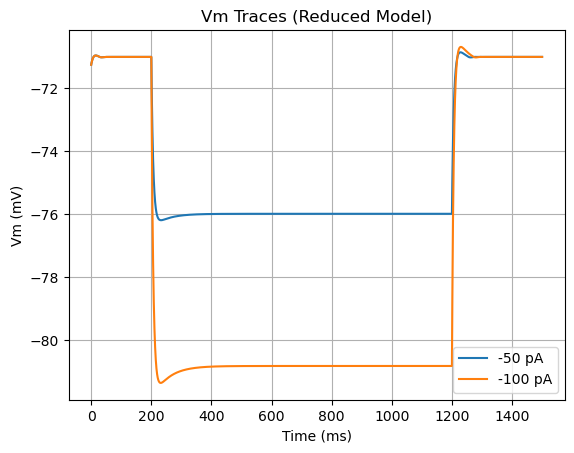

In [31]:
sim_amps = [-50,-100]
# sim_amps = [0.1, 0.15, 0.2, 0.25, 0.3]
sim_params['stim_delay'] = 200
sim_params['stim_dur'] = 1000
sim_params['h_tstop'] = 1500

soma_diam_multiplier = 6 # 3.5/6/10.5

V_traces = {}
spike_freqs = {}

for idx, amp_val in enumerate(sim_amps):
    # 1) set the stimulus amplitude (convert pA → nA)
    sim_params['stim_amp'] = amp_val / 1000.0

    # 2) build *reduced* model: returns (red_soma, detailed_roots, stumps)
    red_soma, det_branches, stumps = build_reduced_cell(stump_props)

    # 3) set up the simulation on red_soma, not hoc_object.soma[0]
    h, stim = set_simulation(red_soma, sim_params)

    # 4) record Vm at the midpoint of red_soma
    v_vec = h.Vector().record(red_soma(0.5)._ref_v)
    #    record time once
    if idx == 0:
        t_vec = h.Vector().record(h._ref_t)

    # 5) initialize and run
    h.finitialize(red_soma.e_pas)   # initialize at the passive reversal
    h.run()

    # 6) grab the results
    V = v_vec.as_numpy()
    T = t_vec.as_numpy()
    V_traces[amp_val] = V

    # 7) compute spike frequency
    f = get_frequency(v_vec, sim_params)
    spike_freqs[amp_val] = f

    # 8) plot
    plt.plot(T, V, label=f"{amp_val} pA")

    # 9) (optional) passive metrics on hyperpolarizing steps
    if amp_val < 0:
        print("Desired Properties: R_in=98.9, tau1=5.9, ..., V_rest=-71.25")
        print(
            ACTPassiveModule.compute_gpp(
                V,
                h.dt,
                sim_params['stim_delay'],
                sim_params['stim_delay'] + sim_params['stim_dur'] - 10,
                amp_val / 1000.0
            )
        )
    else:
        print(f"{amp_val} pA spike frequency = {f:.2f} Hz")

# finalize plot
plt.grid(True)
plt.xlabel("Time (ms)")
plt.ylabel("Vm (mV)")
plt.title("Vm Traces (Reduced Model)")
plt.legend()
plt.show()

Tune Active Properties

1. Single sim with current traces

Reduced-cell Rin = 110.72 MΩ


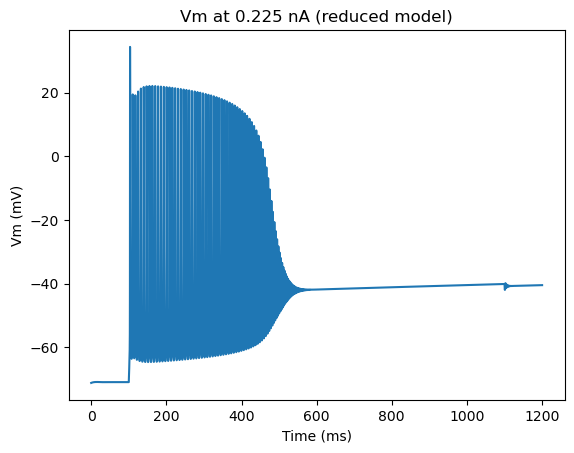

spike frequency = 57.00 Hz


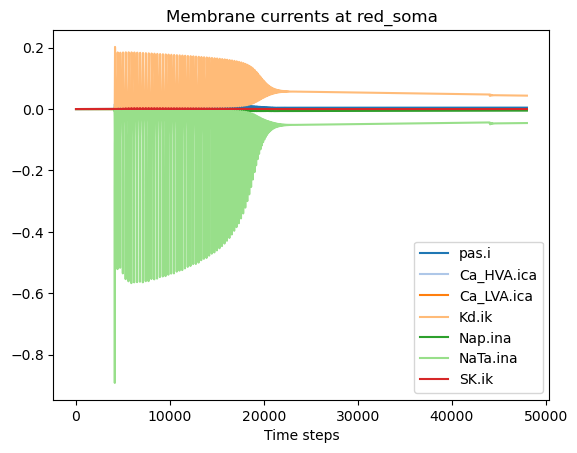

In [32]:
# 0) tweak sim params if you like
sim_params['stim_amp']   = 0.225   # nA
sim_params['stim_delay'] = 100     # ms
sim_params['stim_dur']   = 1000    # ms
sim_params['h_tstop']    = sim_params['stim_delay'] + sim_params['stim_dur'] + 100

# 1) build the reduced model (instead of build_cell)
red_soma, det_branches, stumps = build_reduced_cell(stump_props)

# 2) set up & run the sim on red_soma
h, stim = set_simulation(red_soma, sim_params)

# 3) record Vm and time
v_vec = h.Vector().record(red_soma(0.5)._ref_v)
t_vec = h.Vector().record(h._ref_t)

# 4) record all mech currents at red_soma
current_recording_vars = get_rec_vars_for_i_in_sec(red_soma, 0.5)

# 5) initialize & run
h.finitialize(red_soma.e_pas)
h.run()

# 6) extract and plot Vm
V = v_vec.as_numpy()
T = t_vec.as_numpy()
plt.plot(T, V)
plt.title(f"Vm at {sim_params['stim_amp']} nA (reduced model)")
plt.xlabel("Time (ms)")
plt.ylabel("Vm (mV)")
plt.show()

# 7) spike frequency
print(f"spike frequency = {get_frequency(v_vec, sim_params):.2f} Hz")

# 8) plot selected currents
currents_plotted = ['pas.i','Ca_HVA.ica','Ca_LVA.ica','Kd.ik',
                    'Nap.ina','NaTa.ina','SK.ik']
colors = plt.cm.tab20.colors
i = 0
for name, vec in current_recording_vars.items():
    if name in currents_plotted:
        plt.plot(vec.as_numpy(), color=colors[i], label=name)
        i += 1

plt.legend()
plt.xlabel("Time steps")
plt.title("Membrane currents at red_soma")
plt.show()


2. Multi-sim plot

Reduced-cell Rin = 110.72 MΩ
Desired Properties: R_in=98.9, tau1=5.9, ..., V_rest=-71.25
-0.20399838137960558
GettablePassiveProperties(R_in=99.7, tau1=6.0, tau2=53.0, sag_ratio=0.997, V_rest=-71.0)
Reduced-cell Rin = 110.72 MΩ
Desired Properties: R_in=98.9, tau1=5.9, ..., V_rest=-71.25
-0.538790364436224
GettablePassiveProperties(R_in=98.2, tau1=6.0, tau2=56.4, sag_ratio=0.993, V_rest=-71.0)


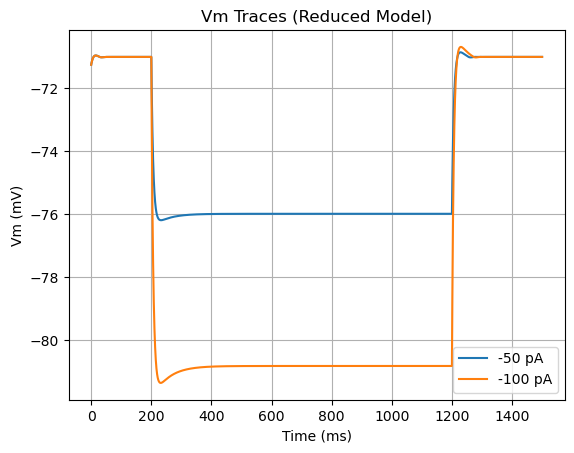

In [33]:
sim_amps = [-50, -100]      # pA steps
sim_params['stim_delay'] = 200    # ms
sim_params['stim_dur']   = 1000   # ms
sim_params['h_tstop']    = 1500   # ms

V_traces    = {}
spike_freqs = {}

for idx, amp_val in enumerate(sim_amps):
    # 1) set stimulus amplitude (convert pA → nA)
    sim_params['stim_amp'] = amp_val / 1000.0

    # 2) build the reduced cell instead of build_cell()
    red_soma, det_branches, stumps = build_reduced_cell(stump_props)

    # 3) set up the simulation on red_soma
    h, stim = set_simulation(red_soma, sim_params)

    # 4) record Vm at red_soma(0.5)
    v_vec = h.Vector().record(red_soma(0.5)._ref_v)
    #    and time only once
    if idx == 0:
        t_vec = h.Vector().record(h._ref_t)

    # 5) initialize & run
    h.finitialize(red_soma.e_pas)
    h.run()

    # 6) grab the data
    V = v_vec.as_numpy()
    T = t_vec.as_numpy()
    V_traces[amp_val]    = V

    # 7) compute spike frequency
    f = get_frequency(v_vec, sim_params)
    spike_freqs[amp_val] = f

    # 8) plot
    plt.plot(T, V, label=f"{amp_val} pA")

    # 9) passive/Q‐value printout for hyperpolarizing steps
    if amp_val < 0:
        print("Desired Properties: R_in=98.9, tau1=5.9, ..., V_rest=-71.25")
        print(
            ACTPassiveModule.compute_gpp(
                V,
                h.dt,
                sim_params['stim_delay'],
                sim_params['stim_delay'] + sim_params['stim_dur'] - 10,
                amp_val / 1000.0
            )
        )
    else:
        print(f"{amp_val} pA spike frequency = {f:.2f} Hz")

# finalize plot
plt.grid(True)
plt.xlabel("Time (ms)")
plt.ylabel("Vm (mV)")
plt.title("Vm Traces (Reduced Model)")
plt.legend()
plt.show()


3. Generate FI Curve

Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ
Reduced-cell Rin = 110.72 MΩ


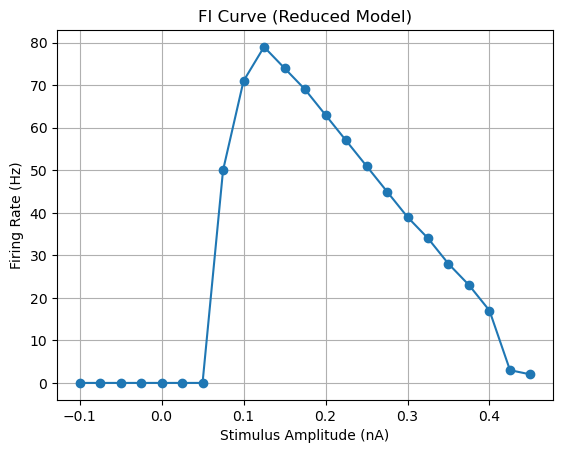

-0.100 nA → 0.00 Hz
-0.075 nA → 0.00 Hz
-0.050 nA → 0.00 Hz
-0.025 nA → 0.00 Hz
0.000 nA → 0.00 Hz
0.025 nA → 0.00 Hz
0.050 nA → 0.00 Hz
0.075 nA → 50.00 Hz
0.100 nA → 71.00 Hz
0.125 nA → 79.00 Hz
0.150 nA → 74.00 Hz
0.175 nA → 69.00 Hz
0.200 nA → 63.00 Hz
0.225 nA → 57.00 Hz
0.250 nA → 51.00 Hz
0.275 nA → 45.00 Hz
0.300 nA → 39.00 Hz
0.325 nA → 34.00 Hz
0.350 nA → 28.00 Hz
0.375 nA → 23.00 Hz
0.400 nA → 17.00 Hz
0.425 nA → 3.00 Hz
0.450 nA → 2.00 Hz


In [34]:
# 0) tweak sim params once
sim_params['stim_delay'] = 100               # ms
sim_params['stim_dur']   = 1000              # ms
sim_params['h_tstop']    = sim_params['stim_delay'] + sim_params['stim_dur'] + 100

# 1) define your current steps (in nA)
amps = [-0.1, -0.075, -0.05, -0.025, 0.0, 0.025, 0.05, 
        0.075, 0.1,  0.125, 0.15,  0.175, 0.2, 0.225, 
        0.25,  0.275, 0.3, 0.325, 0.35,  0.375, 0.4, 
        0.425, 0.45]

frequencies = []

for amp in amps:
    # 2) set the amplitude
    sim_params['stim_amp'] = amp

    # 3) build the reduced model
    # CHECK TO MAKE SURE STEALING DEND WORKS
    red_soma, det_branches, stumps = build_reduced_cell(stump_props)

    # 4) set up & run the sim on red_soma
    h, stim = set_simulation(red_soma, sim_params)

    # 5) record Vm at red_soma(0.5)
    v_vec = h.Vector().record(red_soma(0.5)._ref_v)

    # 6) initialize & run (start at the passive reversal)
    h.finitialize(red_soma.e_pas)
    h.run()

    # 7) compute and store firing rate
    f = get_frequency(v_vec, sim_params)
    frequencies.append(f)

# 8) plot the FI‐curve
plt.plot(amps, frequencies, 'o-')
plt.title("FI Curve (Reduced Model)")
plt.xlabel("Stimulus Amplitude (nA)")
plt.ylabel("Firing Rate (Hz)")
plt.grid(True)
plt.show()

# 9) print out the numbers
for amp, f in zip(amps, frequencies):
    print(f"{amp:.3f} nA → {f:.2f} Hz")
